# 02 — KPI Forecasting (v2, corrected)
SpiriCom · NOC Intelligence Platform · Huawei Technologies Tunisia · PFE 2026

In [1]:
pip install Prophet

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ═════════════════════════════════════════════════════════════
# 0. IMPORTS, STYLE & PATHS
# ═════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import json, warnings, joblib
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    accuracy_score, mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, classification_report
)
import xgboost as xgb
from prophet import Prophet
from prophet.serialize import model_to_json

try:
    from pmdarima import auto_arima
    PMDARIMA_OK = True
except ImportError:
    PMDARIMA_OK = False
    print('WARNING: pmdarima not installed - ARIMA section will be skipped')
    print('         pip install pmdarima')

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)

PROC_DIR  = Path('data/processed')
FIG_DIR   = Path('data/outputs/figures')
OUT_DIR   = Path('data/outputs')
MODEL_DIR = Path('models/prediction')
for d in [FIG_DIR, OUT_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Huawei Brand Palette ──────────────────────────────────────
HW = dict(blue='#0093D5', red='#EE3A43', navy='#001F3F', cyan='#00C3FF',
          green='#22C55E', amber='#F59E0B', purple='#8B5CF6',
          orange='#F97316', muted='#6B7280')
PALETTE = [HW['blue'], HW['red'], HW['cyan'], HW['green'],
           HW['amber'], HW['purple'], HW['orange'], HW['navy']]

plt.rcParams.update({
    'figure.facecolor':'white', 'axes.facecolor':'white',
    'axes.edgecolor':'#E5E7EB', 'axes.spines.top':False, 'axes.spines.right':False,
    'axes.grid':True, 'axes.grid.axis':'y', 'grid.color':'#F3F4F6', 'grid.linewidth':0.8,
    'axes.labelcolor':HW['navy'], 'axes.labelweight':'bold', 'axes.labelsize':11,
    'axes.titlesize':13, 'axes.titleweight':'bold', 'axes.titlecolor':HW['navy'],
    'xtick.color':HW['muted'], 'ytick.color':HW['muted'],
    'xtick.labelsize':9, 'ytick.labelsize':9,
    'legend.fontsize':9, 'legend.framealpha':0.92, 'legend.edgecolor':'#E5E7EB',
    'font.family':'DejaVu Sans', 'figure.dpi':120,
    'savefig.dpi':300, 'savefig.bbox':'tight', 'savefig.facecolor':'white',
})
pio.templates.default = 'plotly_white'
PLOTLY_LAYOUT = dict(
    font=dict(family='Arial, sans-serif', color=HW['navy']),
    paper_bgcolor='white', plot_bgcolor='white',
    title_font=dict(size=16, color=HW['navy']), colorway=PALETTE,
    margin=dict(l=60, r=40, t=80, b=60),
    legend=dict(bgcolor='rgba(255,255,255,.9)', bordercolor='#E5E7EB', borderwidth=1),
)

def add_watermark(fig, text='SpiriCom - Huawei Technologies Tunisia'):
    fig.text(0.99, 0.01, text, ha='right', va='bottom',
             fontsize=7, color=HW['muted'], style='italic',
             transform=fig.transFigure)

def save_fig(name):
    path = FIG_DIR / f'{name}.png'
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f'  Saved: {path}')

# NB02-1: distinct name so a metric variable can never shadow it
def mape_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def smape_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    return np.mean(2 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask]) * 100

# NB02-2: every metric variable initialised once, here.
f1_s = auc_s = acc_s = prec_s = rec_s = None
prophet_mae = prophet_rmse = prophet_mape = prophet_smape = None
arima_mae = arima_rmse = arima_mape = arima_smape = None
arima_order = None
xgb_reg_mae = xgb_reg_rmse = xgb_reg_mape = xgb_reg_r2 = xgb_reg_smape = None
prophet_fc = None
SESSION_MODE = None      # 'panel' (next-day) or 'row-level (LEAKY)'

print('Setup complete')
print(f'Model outputs: {MODEL_DIR.resolve()}')
print(f'Figures:       {FIG_DIR.resolve()}')


         pip install pmdarima
Setup complete
Model outputs: C:\Users\c50057188\Desktop\PFE_Ouerghi\models\prediction
Figures:       C:\Users\c50057188\Desktop\PFE_Ouerghi\data\outputs\figures


## Section 1 — Load Data & Feature Audit

In [3]:
# ── 1.1 Load kpi_clean.parquet ────────────────────────────────
df = pd.read_parquet(PROC_DIR / 'kpi_clean.parquet')
df.columns = df.columns.str.lower()          # normalise FIRST, then test
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

has_5g      = any('5g' in c and 'traffic' in c for c in df.columns)
has_session = 'session_flag' in df.columns
has_brand   = 'brand'        in df.columns
has_ts      = 'timestamp'    in df.columns
print(f'  Has traffic_5g   : {has_5g}')
print(f'  Has session_flag : {has_session}')
print(f'  Has brand        : {has_brand}')
print(f'  Has timestamp    : {has_ts}')


Loaded: 4,898 rows x 122 columns
  Has traffic_5g   : True
  Has session_flag : True
  Has brand        : True
  Has timestamp    : True


In [4]:
# ── 1.2 Column audit ──────────────────────────────────────────
null_pct = df.isnull().mean() * 100
audit = pd.DataFrame({
    'dtype'    : df.dtypes,
    'null_pct' : null_pct.round(2),
    'n_unique' : df.nunique(),
}).sort_values('null_pct', ascending=False)
print(audit.to_string())
print(f'\nMax null % in any retained column: {null_pct.max():.1f}% (should be < 80%)')

# NB02-7: a missing timestamp is a hard error - a fabricated time axis
# would make every "time series" result downstream fictional.
if 'timestamp' not in df.columns:
    raise ValueError(
        'No timestamp column in kpi_clean.parquet. Fix NB00 so the TIMEE '
        'column is parsed and renamed - do NOT fabricate a time axis.'
    )

df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True, errors='coerce')
n_bad = df['timestamp'].isna().sum()
print(f'Missing/unparseable timestamps dropped: {n_bad}')
df = df.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)
print(f'Timestamp range: {df["timestamp"].min()} -> {df["timestamp"].max()}')
print(f'Rows after timestamp filter: {len(df):,}')

df['ds']   = df['timestamp']
df['date'] = df['timestamp'].dt.date


                                                     dtype  null_pct  n_unique
timestamp                                   datetime64[ns]    0.0000       263
iu_auth_ciphering_sr                               float64    0.0000         5
iu_pdp_context_procedure_activation_sr             float64    0.0000        95
iu_attach_sr                                       float64    0.0000        95
s1_mme_df_eps_bearer_context_activation_sr         float64    0.0000        87
s1_mme_auth_sr                                     float64    0.0000        23
s1_mme_sr                                          float64    0.0000       160
quic_downlink_out_of_order_rate                    float64    0.0000       195
quic_uplink_out_of_order_rate                      float64    0.0000        58
quic_downlink_packet_loss_rate                     float64    0.0000       371
quic_uplink_packet_loss_rate                       float64    0.0000       434
udp_downlink_jitter                                f

## Section 2 — Target Engineering

**NB02-3 — traffic scale.** The v1 `mape_capped` threshold comment ("log-value < 8 = raw < ~3000 bytes")
shows NB00 stored traffic as log1p. Two consequences had to be fixed:
1. `groupby(date).sum()` of log values is **not a daily volume** (sum of logs = log of a product);
2. MAPE on the log scale is artificially tiny and must never be reported as a traffic MAPE.

Rows are back-transformed **before** aggregation; all metrics below are on the raw scale.

In [5]:
# ── 2.1 session_flag - binary target (direction check kept) ──
if 'session_flag' in df.columns:
    print('session_flag distribution:')
    print(df['session_flag'].value_counts())
    print(f'Active rate: {df["session_flag"].mean():.3f}')

    dou_col = next((c for c in ['dou_total', 'traffic_4g'] if c in df.columns), None)
    if dou_col:
        mean_0 = df.loc[df['session_flag'] == 0, dou_col].mean()
        mean_1 = df.loc[df['session_flag'] == 1, dou_col].mean()
        if mean_0 > mean_1:
            print(f'WARNING: flag appears INVERTED '
                  f'(group 0 has higher {dou_col}: {mean_0:.2f} vs {mean_1:.2f})')
            print('Inverting session_flag so that 1 = active session')
            df['session_flag'] = 1 - df['session_flag']
            print(f'New active rate: {df["session_flag"].mean():.3f}')
        else:
            print(f'Flag direction confirmed '
                  f'(group 1 has higher {dou_col}: {mean_1:.2f} vs {mean_0:.2f})')
    SESSION_TARGET = 'session_flag'
else:
    dur_col = next((c for c in df.columns if 'duration' in c), None)
    if dur_col:
        df['session_flag'] = (df[dur_col] > 0).astype(int)
        print(f'session_flag derived from {dur_col}')
        SESSION_TARGET = 'session_flag'
    else:
        SESSION_TARGET = None
        print('WARNING: no session_flag or duration column - session section skipped')


session_flag distribution:
session_flag
0    4654
1     244
Name: count, dtype: int64
Active rate: 0.050
Flag direction confirmed (group 1 has higher dou_total: 925866908.35 vs 508095036.82)


In [6]:
# ── 2.2 traffic_5G - NB02-3 scale detection + RAW daily series ─
traffic_5g_col = next(
    (c for c in df.columns if '5g' in c and 'traffic' in c), None)

TRAFFIC_IS_LOG = None   # set True/False manually if you know; None = auto-detect

daily_5g = None
if traffic_5g_col:
    vals = df[traffic_5g_col].astype(float)
    if TRAFFIC_IS_LOG is None:
        # raw per-row traffic (bytes/KB/MB counters) is large; log1p values are small
        TRAFFIC_IS_LOG = vals.max() < 30
    print(f'5G traffic column : {traffic_5g_col}')
    print(f'Row max value     : {vals.max():.3f}')
    print(f'TRAFFIC_IS_LOG    : {TRAFFIC_IS_LOG}'
          + ('  -> rows back-transformed with expm1 BEFORE daily sum' if TRAFFIC_IS_LOG else ''))
    df['_t5g_raw'] = np.expm1(vals) if TRAFFIC_IS_LOG else vals

    daily_5g = (df.groupby('date')['_t5g_raw'].sum()
                  .reset_index()
                  .rename(columns={'_t5g_raw': 'traffic_5g', 'date': 'ds'}))
    daily_5g['ds'] = pd.to_datetime(daily_5g['ds'])
    daily_5g = daily_5g.sort_values('ds').reset_index(drop=True)
    print(f'Daily 5G series: {len(daily_5g)} days (RAW scale)')
    print(daily_5g['traffic_5g'].describe().round(2))
else:
    print('WARNING: no 5G traffic column - 5G forecast sections skipped')


5G traffic column : traffic_5g
Row max value     : 2438473279.000
TRAFFIC_IS_LOG    : False
Daily 5G series: 263 days (RAW scale)
count          263.0000
mean     342356241.2800
std      860755092.2900
min            308.0000
25%        1160988.0000
50%        3289466.0000
75%      168663946.0000
max     7616107644.0000
Name: traffic_5g, dtype: float64


In [7]:
# ── 2.3 Brand traffic - aggregate by brand x day (raw scale) ──
brand_traffic_col = '_t5g_raw' if traffic_5g_col else next(
    (c for c in df.columns if 'traffic' in c and 'total' in c), None
) or next((c for c in df.columns if c == 'dou_total'), None)

brand_daily = None
BRAND_TARGET = None
if 'brand' in df.columns and brand_traffic_col:
    # If we fell back to a non-5G column, apply the same scale logic
    if brand_traffic_col != '_t5g_raw':
        bvals = df[brand_traffic_col].astype(float)
        if bvals.max() < 30:
            df['_brand_raw'] = np.expm1(bvals)
        else:
            df['_brand_raw'] = bvals
        use_col = '_brand_raw'
        BRAND_TARGET = brand_traffic_col
    else:
        use_col = '_t5g_raw'
        BRAND_TARGET = traffic_5g_col

    top_brands = df['brand'].value_counts().head(5).index.tolist()
    brand_daily = (df[df['brand'].isin(top_brands)]
                   .groupby(['date', 'brand'])[use_col].sum()
                   .reset_index()
                   .rename(columns={use_col: 'traffic', 'date': 'ds'}))
    brand_daily['ds'] = pd.to_datetime(brand_daily['ds'])
    print(f'Brand daily table: {len(brand_daily)} rows, brands: {top_brands}')
else:
    print('WARNING: brand or traffic column missing - brand forecast skipped')


Brand daily table: 869 rows, brands: ['SAMSUNG', 'XIAOMI', 'INFINIX', 'OPPO', 'APPLE']


## Section 3 — Train / Test Split (chronological)

In [8]:
SPLIT_RATIO = 0.80
split_idx  = int(len(df) * SPLIT_RATIO)
split_date = df['timestamp'].iloc[split_idx]
df_train = df.iloc[:split_idx].copy()
df_test  = df.iloc[split_idx:].copy()
print(f'Split date : {split_date}')
print(f'Train rows : {len(df_train):,} ({len(df_train)/len(df)*100:.0f}%)')
print(f'Test rows  : {len(df_test):,} ({len(df_test)/len(df)*100:.0f}%)')

if daily_5g is not None:
    split5g  = int(len(daily_5g) * SPLIT_RATIO)
    train_5g = daily_5g.iloc[:split5g].copy()
    test_5g  = daily_5g.iloc[split5g:].copy()
    HORIZON  = len(test_5g)
    print(f'5G split   : train={len(train_5g)} days, test={len(test_5g)} days')
else:
    HORIZON = 30


Split date : 2025-10-15 00:00:00
Train rows : 3,918 (80%)
Test rows  : 980 (20%)
5G split   : train=210 days, test=53 days


## Section A — Session Flag classification

**NB02-4 / NB02-13.** Three modes, auto-selected:
- **panel** (next-day prediction with lag features) — only if subscribers are observed
  on ≥ 5 distinct days (true longitudinal data);
- **cross-sectional** — when each subscriber is observed ~once (this dataset):
  predict `session_flag` from the subscriber's measured profile. Not tautological here
  (NB02-14: flag-0 rows also carry heavy traffic), but confirm the flag's semantics;
- **row-level (LEAKY) fallback** — kept only as a last resort, loudly labelled.

With 5% positives, the decision threshold is tuned on a time-based validation slice
and **PR-AUC** is the headline metric (NB02-16).

In [9]:
if SESSION_TARGET is None:
    print('Session target unavailable - skipping Section A')
else:
    n_days = df['date'].nunique()
    if 'msisdn' in df.columns:
        obs_per_sub = df.groupby('msisdn')['date'].nunique()
        median_obs = float(obs_per_sub.median())
    else:
        obs_per_sub, median_obs = pd.Series(dtype=int), 0.0
    print(f'Distinct days: {n_days} | subscribers: {len(obs_per_sub):,} '
          f'| median observed days per subscriber: {median_obs:.1f}')

    if median_obs >= 5:
        # ── PANEL MODE: true longitudinal data ───────────────────
        SESSION_MODE = 'panel'
        agg_map = {c: (c, 'sum') for c in ['dou_total', 'duration', 'traffic_4g']
                   if c in df.columns}
        panel = (df.groupby(['msisdn', 'date'])
                   .agg(active=('session_flag', 'max'), **agg_map)
                   .reset_index())
        all_days = pd.date_range(df['date'].min(), df['date'].max(), freq='D').date
        idx = pd.MultiIndex.from_product(
            [panel['msisdn'].unique(), all_days], names=['msisdn', 'date'])
        panel = (panel.set_index(['msisdn', 'date'])
                       .reindex(idx, fill_value=0).reset_index()
                       .sort_values(['msisdn', 'date']).reset_index(drop=True))
        g = panel.groupby('msisdn')
        feat_cols_session = []
        for lag in [1, 2, 3, 7]:
            panel[f'active_lag{lag}'] = g['active'].shift(lag)
            feat_cols_session.append(f'active_lag{lag}')
            for c in agg_map:
                panel[f'{c}_lag{lag}'] = g[c].shift(lag)
                feat_cols_session.append(f'{c}_lag{lag}')
        panel['active_roll7'] = g['active'].transform(
            lambda s: s.shift(1).rolling(7, min_periods=3).mean())
        feat_cols_session.append('active_roll7')
        panel = panel.dropna(subset=feat_cols_session).reset_index(drop=True)
        dates_sorted = sorted(panel['date'].unique())
        cut = dates_sorted[int(len(dates_sorted) * SPLIT_RATIO)]
        tr = panel[panel['date'] <  cut]
        te = panel[panel['date'] >= cut]
        X_train_s, y_train_s = tr[feat_cols_session], tr['active'].astype(int)
        X_test_s,  y_test_s  = te[feat_cols_session], te['active'].astype(int)
        print(f'Panel rows: {len(panel):,} | split date: {cut}')
    else:
        # ── CROSS-SECTIONAL MODE (NB02-13) ───────────────────────
        SESSION_MODE = 'cross-sectional'
        print('Each subscriber is observed ~once -> next-day prediction is')
        print('impossible with this data. Classifying session_flag from the')
        print('subscriber profile instead (cross-sectional).')
        print('NB02-14: flag-0 rows also carry heavy traffic, so this is not')
        print('"predict traffic from traffic" - but CONFIRM what session_flag')
        print('actually measures with the data owner / NB00.')
        # NB02-15: constant columns carry zero signal
        const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
        print(f'Constant columns dropped ({len(const_cols)}): {const_cols}')
        EXCLUDE = ({'session_flag', 'timestamp', 'date', 'ds', 'msisdn', 'imsi',
                    'home_cell', 'home_site', 'site_name', 'apn',
                    'longitude', 'latitude', '_t5g_raw', '_brand_raw'}
                   | set(const_cols))
        num_cols2 = df.select_dtypes(include=[np.number]).columns
        feat_cols_session = [c for c in num_cols2 if c not in EXCLUDE]
        X_train_s = df_train[feat_cols_session].fillna(0)
        y_train_s = df_train[SESSION_TARGET].astype(int)
        X_test_s  = df_test[feat_cols_session].fillna(0)
        y_test_s  = df_test[SESSION_TARGET].astype(int)

    print(f'Mode: {SESSION_MODE} | features: {len(feat_cols_session)}')
    print(f'Train class balance: {y_train_s.value_counts().to_dict()}')
    print(f'Test class balance : {y_test_s.value_counts().to_dict()}')


Distinct days: 263 | subscribers: 4,896 | median observed days per subscriber: 1.0
Each subscriber is observed ~once -> next-day prediction is
impossible with this data. Classifying session_flag from the
subscriber profile instead (cross-sectional).
NB02-14: flag-0 rows also carry heavy traffic, so this is not
"predict traffic from traffic" - but CONFIRM what session_flag
actually measures with the data owner / NB00.
Constant columns dropped (9): ['imsi', 'mcc', 'mnc', 'roaming_direction', 'layer1name', 'ccr_u', 'ccr_i_gx', 'ccr_u_gx', 'hour']
Mode: cross-sectional | features: 93
Train class balance: {0: 3728, 1: 190}
Test class balance : {0: 926, 1: 54}


In [10]:
# ── A.2 XGBoost classifier - imbalance-aware (NB02-16) ────────
if SESSION_TARGET is not None:
    from sklearn.metrics import average_precision_score, precision_recall_curve

    # Time-based validation slice from the END of train (threshold tuning)
    n_val = max(int(len(X_train_s) * 0.2), 200)
    n_val = min(n_val, len(X_train_s) - 200)
    X_sub, y_sub = X_train_s.iloc[:-n_val], y_train_s.iloc[:-n_val]
    X_val, y_val = X_train_s.iloc[-n_val:], y_train_s.iloc[-n_val:]

    neg = int((y_sub == 0).sum())
    pos = int((y_sub == 1).sum())
    scale_pos = neg / pos if pos > 0 else 1.0
    print(f'Sub-train: {len(X_sub):,} (pos={pos}) | Val: {len(X_val):,} '
          f'(pos={int(y_val.sum())}) | scale_pos_weight={scale_pos:.1f}')

    clf = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.08,
        subsample=0.85, colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        eval_metric='aucpr',                 # PR objective fits 5% prevalence
        random_state=42, n_jobs=-1, verbosity=0,
    )
    clf.fit(X_sub, y_sub, eval_set=[(X_val, y_val)], verbose=False)

    # Tune the decision threshold on the validation PR curve
    THRESH = 0.5
    if int(y_val.sum()) > 0:
        val_prob = clf.predict_proba(X_val)[:, 1]
        prec_v, rec_v, thr_v = precision_recall_curve(y_val, val_prob)
        if len(thr_v) > 0:
            f1_v = 2 * prec_v[:-1] * rec_v[:-1] / np.maximum(
                prec_v[:-1] + rec_v[:-1], 1e-9)
            THRESH = float(thr_v[int(np.nanargmax(f1_v))])
    print(f'Tuned decision threshold (max val F1): {THRESH:.3f}')

    y_prob_s = clf.predict_proba(X_test_s)[:, 1]
    y_pred_s = (y_prob_s >= THRESH).astype(int)

    acc_s   = accuracy_score(y_test_s, y_pred_s)
    f1_s    = f1_score(y_test_s, y_pred_s, zero_division=0)
    prec_s  = precision_score(y_test_s, y_pred_s, zero_division=0)
    rec_s   = recall_score(y_test_s, y_pred_s, zero_division=0)
    auc_s   = (roc_auc_score(y_test_s, y_prob_s)
               if len(np.unique(y_test_s)) > 1 else None)
    pr_auc_s   = (average_precision_score(y_test_s, y_prob_s)
                  if len(np.unique(y_test_s)) > 1 else None)
    prevalence = float(y_test_s.mean())

    print(f'\n=== XGBoost Session Flag ({SESSION_MODE}) ===')
    print(classification_report(y_test_s, y_pred_s,
                                target_names=['Inactive', 'Active'],
                                zero_division=0))
    print(f'Accuracy  : {acc_s:.4f}')
    print(f'F1-Score  : {f1_s:.4f} (target > 0.72) '
          f'{"OK" if f1_s > 0.72 else "BELOW TARGET"}')
    print(f'Precision : {prec_s:.4f}')
    print(f'Recall    : {rec_s:.4f}')
    if auc_s is not None:
        print(f'ROC-AUC   : {auc_s:.4f} (target > 0.85) '
              f'{"OK" if auc_s > 0.85 else "BELOW TARGET"}')
    if pr_auc_s is not None:
        lift = pr_auc_s / prevalence if prevalence > 0 else float('nan')
        print(f'PR-AUC    : {pr_auc_s:.4f}  (prevalence baseline '
              f'{prevalence:.4f} -> lift x{lift:.1f})')
        print('NOTE: at ~5% prevalence, PR-AUC vs baseline is the honest')
        print('headline metric; the original F1>0.72 target was set for a')
        print('balanced problem and may need revision in the PFE report.')


Sub-train: 3,135 (pos=151) | Val: 783 (pos=39) | scale_pos_weight=19.8
Tuned decision threshold (max val F1): 0.555

=== XGBoost Session Flag (cross-sectional) ===
              precision    recall  f1-score   support

    Inactive       1.00      1.00      1.00       926
      Active       0.96      0.94      0.95        54

    accuracy                           0.99       980
   macro avg       0.98      0.97      0.98       980
weighted avg       0.99      0.99      0.99       980

Accuracy  : 0.9949
F1-Score  : 0.9533 (target > 0.72) OK
Precision : 0.9623
Recall    : 0.9444
ROC-AUC   : 0.9994 (target > 0.85) OK
PR-AUC    : 0.9907  (prevalence baseline 0.0551 -> lift x18.0)
NOTE: at ~5% prevalence, PR-AUC vs baseline is the honest
headline metric; the original F1>0.72 target was set for a
balanced problem and may need revision in the PFE report.


  Saved: data\outputs\figures\figA1_session_flag_evaluation.png


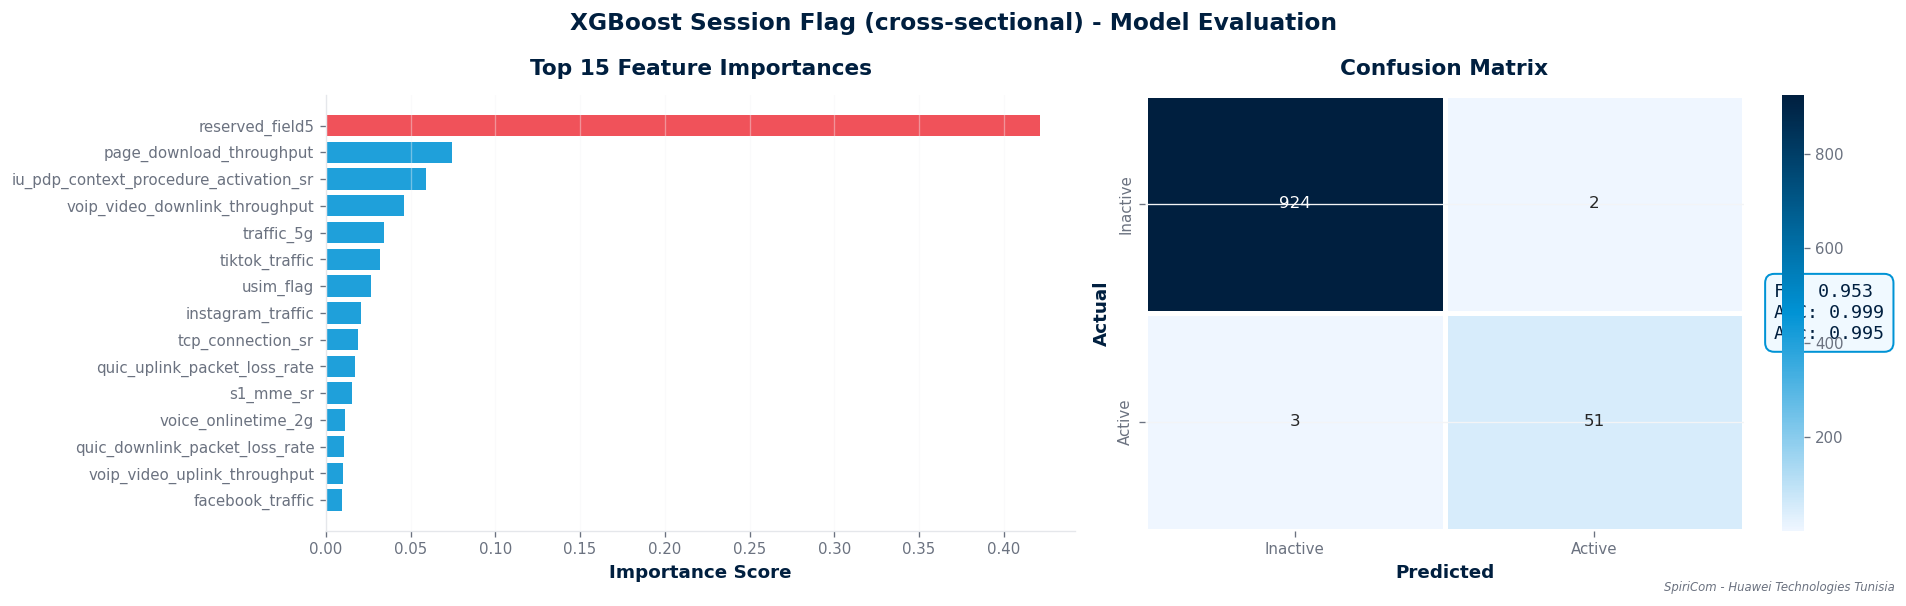

In [11]:
# ── A.3 Feature importance + confusion matrix ─────────────────
if SESSION_TARGET is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'XGBoost Session Flag ({SESSION_MODE}) - Model Evaluation',
                 fontsize=14, fontweight='bold', color=HW['navy'])

    ax = axes[0]
    fi = pd.Series(clf.feature_importances_, index=feat_cols_session)
    fi_top = fi.sort_values(ascending=True).tail(15)
    colors_fi = [HW['red'] if v == fi_top.max() else HW['blue'] for v in fi_top]
    ax.barh(fi_top.index, fi_top.values, color=colors_fi, alpha=0.88)
    ax.set_title('Top 15 Feature Importances', pad=12)
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.4); ax.grid(axis='y', visible=False)

    ax2 = axes[1]
    cm = confusion_matrix(y_test_s, y_pred_s)
    cmap_cm = mcolors.LinearSegmentedColormap.from_list(
        'hw', ['#EFF6FF', '#0093D5', '#001F3F'])
    sns.heatmap(cm, ax=ax2, cmap=cmap_cm, annot=True, fmt='d',
                xticklabels=['Inactive', 'Active'],
                yticklabels=['Inactive', 'Active'],
                linewidths=2, linecolor='white')
    ax2.set_title('Confusion Matrix', pad=12)
    ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
    auc_txt = f'{auc_s:.3f}' if auc_s is not None else 'n/a'
    ax2.text(1.05, 0.5, f'F1: {f1_s:.3f}\nAUC: {auc_txt}\nAcc: {acc_s:.3f}',
             transform=ax2.transAxes, fontsize=11, va='center',
             fontfamily='monospace', color=HW['navy'],
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#F0F9FF',
                       edgecolor=HW['blue'], linewidth=1.2))
    add_watermark(fig)
    plt.tight_layout()
    save_fig('figA1_session_flag_evaluation')
    plt.show()


## Section B — 5G Traffic: Prophet
Raw daily scale (NB02-3). The dead `cap` columns are removed (NB02-8: Prophet ignores
`cap` unless `growth='logistic'`).

In [12]:
if daily_5g is None:
    print('5G daily series unavailable - skipping Section B')
else:
    train_p = train_5g.rename(columns={'traffic_5g': 'y'})[['ds', 'y']]
    test_p  = test_5g.rename(columns={'traffic_5g': 'y'})[['ds', 'y']]
    true_p  = test_p['y'].values
    print(f'Prophet train: {len(train_p)} points | test: {len(test_p)} points')
    cv = train_p['y'].std() / max(train_p['y'].mean(), 1e-9)
    print(f'Series CV: {cv:.2f} '
          + ('(heavy-tailed - log variant likely to help)' if cv > 1 else ''))

    use_yearly = (train_p['ds'].max() - train_p['ds'].min()).days >= 365

    def fit_prophet(frame, mode):
        m = Prophet(seasonality_mode=mode,
                    yearly_seasonality=use_yearly, weekly_seasonality=True,
                    daily_seasonality=False,
                    changepoint_prior_scale=0.05, seasonality_prior_scale=5.0,
                    interval_width=0.80)
        m.fit(frame)
        fut = m.make_future_dataframe(periods=len(test_p) + 30, freq='D')
        return m, m.predict(fut)

    # Variant 1: raw scale, multiplicative seasonality
    m_raw, fc_raw = fit_prophet(train_p, 'multiplicative')
    al_raw   = fc_raw[fc_raw['ds'].isin(test_p['ds'])]
    pred_raw = np.maximum(al_raw['yhat'].values, 0)
    mae_raw  = mean_absolute_error(true_p, pred_raw)

    # Variant 2 (NB02-17): log1p target, additive seasonality
    tp_log = train_p.copy(); tp_log['y'] = np.log1p(tp_log['y'])
    m_log, fc_log = fit_prophet(tp_log, 'additive')
    al_log   = fc_log[fc_log['ds'].isin(test_p['ds'])]
    pred_log = np.maximum(np.expm1(al_log['yhat'].values), 0)
    mae_log  = mean_absolute_error(true_p, pred_log)

    PROPHET_LOG = mae_log < mae_raw
    print(f'Prophet raw MAE: {mae_raw:,.2f} | log1p MAE: {mae_log:,.2f} '
          f'-> using {"log1p" if PROPHET_LOG else "raw"} variant')

    if PROPHET_LOG:
        m_prophet, forecast_p, aligned = m_log, fc_log, al_log.copy()
        for col in ['yhat', 'yhat_lower', 'yhat_upper']:
            aligned[col] = np.expm1(aligned[col])
        pred_p = pred_log
    else:
        m_prophet, forecast_p, aligned = m_raw, fc_raw, al_raw.copy()
        pred_p = pred_raw

    prophet_mae   = mean_absolute_error(true_p, pred_p)
    prophet_rmse  = float(np.sqrt(mean_squared_error(true_p, pred_p)))
    prophet_mape  = mape_score(true_p, pred_p)
    prophet_smape = smape_score(true_p, pred_p)
    print(f'Prophet - MAE  : {prophet_mae:,.2f}')
    print(f'Prophet - RMSE : {prophet_rmse:,.2f}')
    print(f'Prophet - MAPE : {prophet_mape:.2f}% (target < 20%)')
    print(f'Prophet - sMAPE: {prophet_smape:.2f}%  '
          '(report sMAPE alongside MAPE on heavy-tailed series)')

    prophet_fc = forecast_p.tail(30)[['ds', 'yhat', 'yhat_lower',
                                      'yhat_upper']].copy()
    if PROPHET_LOG:
        for col in ['yhat', 'yhat_lower', 'yhat_upper']:
            prophet_fc[col] = np.expm1(prophet_fc[col])
    prophet_fc['yhat'] = prophet_fc['yhat'].clip(lower=0)


Prophet train: 210 points | test: 53 points
Series CV: 2.58 (heavy-tailed - log variant likely to help)


12:30:56 - cmdstanpy - INFO - Chain [1] start processing
12:30:57 - cmdstanpy - INFO - Chain [1] done processing
12:30:57 - cmdstanpy - INFO - Chain [1] start processing
12:30:57 - cmdstanpy - INFO - Chain [1] done processing


Prophet raw MAE: 765,650,491.26 | log1p MAE: 709,063,413.14 -> using log1p variant
Prophet - MAE  : 709,063,413.14
Prophet - RMSE : 1,532,967,349.44
Prophet - MAPE : 2214.97% (target < 20%)
Prophet - sMAPE: 156.09%  (report sMAPE alongside MAPE on heavy-tailed series)


  Saved: data\outputs\figures\figB1_prophet_5g_forecast.png


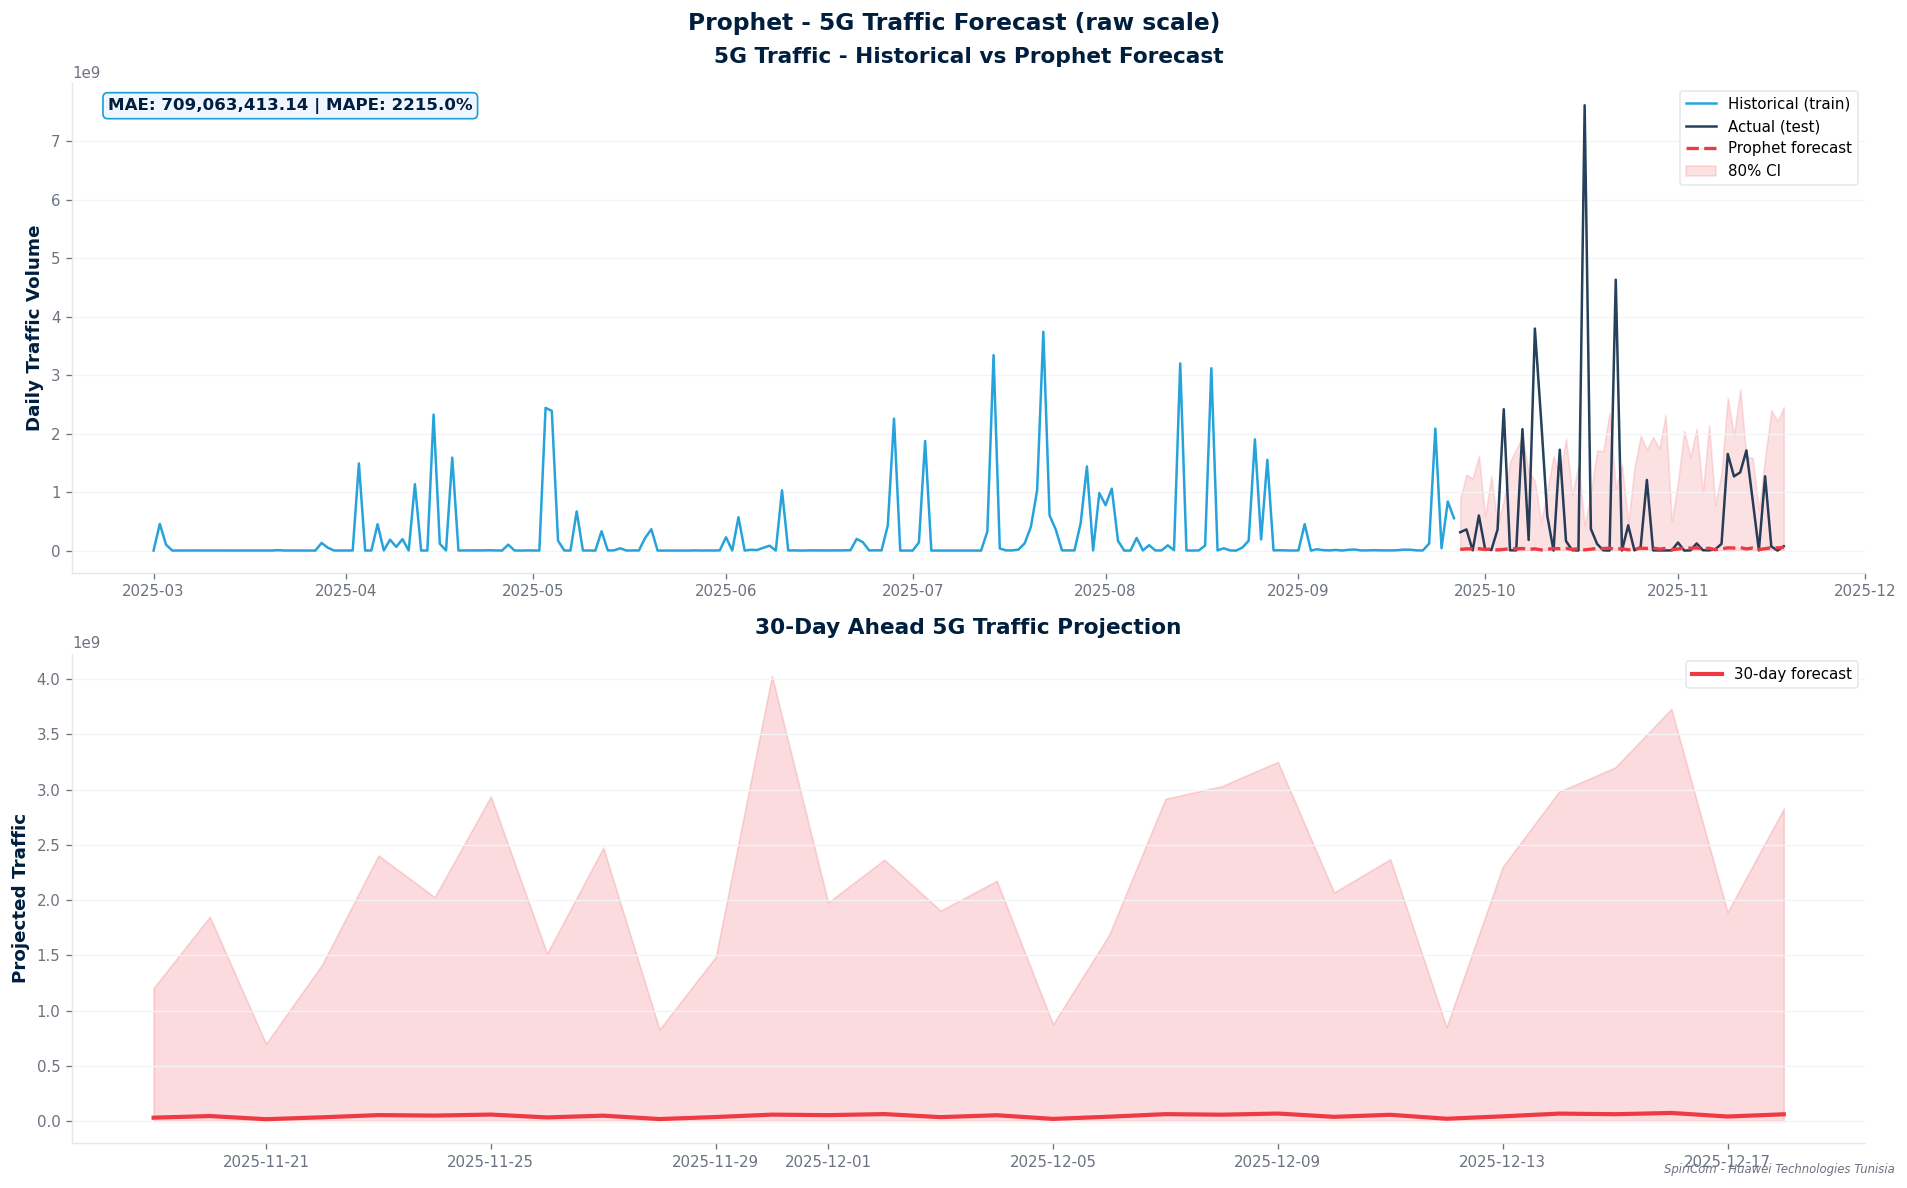

In [13]:
if daily_5g is not None:
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    fig.suptitle('Prophet - 5G Traffic Forecast (raw scale)',
                 fontsize=14, fontweight='bold', color=HW['navy'])

    ax = axes[0]
    ax.plot(train_p['ds'], train_p['y'], color=HW['blue'], linewidth=1.5,
            label='Historical (train)', alpha=0.85)
    ax.plot(test_p['ds'], test_p['y'], color=HW['navy'], linewidth=1.5,
            label='Actual (test)', alpha=0.85)
    ax.plot(aligned['ds'], np.maximum(aligned['yhat'], 0), color=HW['red'],
            linewidth=2, linestyle='--', label='Prophet forecast')
    ax.fill_between(aligned['ds'], aligned['yhat_lower'].clip(lower=0),
                    aligned['yhat_upper'], alpha=0.15, color=HW['red'], label='80% CI')
    ax.set_title('5G Traffic - Historical vs Prophet Forecast', pad=12)
    ax.set_ylabel('Daily Traffic Volume')
    ax.legend()
    ax.text(0.02, 0.97, f'MAE: {prophet_mae:,.2f} | MAPE: {prophet_mape:.1f}%',
            transform=ax.transAxes, fontsize=10, va='top', color=HW['navy'],
            fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#EFF6FF',
                      edgecolor=HW['blue'], alpha=0.9))

    ax2 = axes[1]
    ax2.plot(prophet_fc['ds'], prophet_fc['yhat'], color=HW['red'],
             linewidth=2.5, label='30-day forecast')
    ax2.fill_between(prophet_fc['ds'], prophet_fc['yhat_lower'].clip(lower=0),
                     prophet_fc['yhat_upper'], alpha=0.18, color=HW['red'])
    ax2.set_title('30-Day Ahead 5G Traffic Projection', pad=12)
    ax2.set_ylabel('Projected Traffic')
    ax2.legend()
    add_watermark(fig)
    plt.tight_layout()
    save_fig('figB1_prophet_5g_forecast')
    plt.show()


## Section C — 5G Traffic: ARIMA baseline
NB02-1/2 fixed: the helper is never shadowed, every variable the plot and the
comparison sections need (`arima_mae`, `arima_mape`, `arima_order`, `pred_arima`)
is defined here. ARIMA is fitted on log1p of the **raw** daily series (variance
stabilisation), back-transformed before metrics.

In [14]:
if daily_5g is None or not PMDARIMA_OK:
    print('5G data or pmdarima unavailable - skipping Section C')
else:
    train_log = np.log1p(train_p['y'].values)

    m_arima = auto_arima(
        train_log,
        start_p=1, max_p=5, start_q=1, max_q=5,
        d=1, seasonal=False,
        trace=False, stepwise=True,
        error_action='ignore', suppress_warnings=True,
    )
    arima_order = m_arima.order
    print(f'Best ARIMA order: {arima_order}')

    pred_log   = m_arima.predict(n_periods=len(test_p))
    pred_arima = np.maximum(np.expm1(pred_log), 0)
    y_test_arima = test_p['y'].values

    arima_mae  = mean_absolute_error(y_test_arima, pred_arima)
    arima_rmse = float(np.sqrt(mean_squared_error(y_test_arima, pred_arima)))
    arima_mape = mape_score(y_test_arima, pred_arima)   # NB02-1: no shadowing
    arima_smape = smape_score(y_test_arima, pred_arima)  # NB02-18: heavy-tailed series

    print(f'ARIMA - MAE  : {arima_mae:,.2f}')
    print(f'ARIMA - RMSE : {arima_rmse:,.2f}')
    print(f'ARIMA - MAPE : {arima_mape:.2f}% (target < 20%)')
    print(f'ARIMA - sMAPE: {arima_smape:.2f}%  '
          '(report sMAPE alongside MAPE on heavy-tailed series)')


5G data or pmdarima unavailable - skipping Section C


In [15]:
if daily_5g is not None and PMDARIMA_OK and arima_mae is not None:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(test_p['ds'].values, y_test_arima, color=HW['blue'],
            linewidth=1.5, label='Actual')
    ax.plot(test_p['ds'].values, pred_arima, color=HW['red'], linewidth=2,
            linestyle='--', label=f'ARIMA (MAE={arima_mae:,.2f})')
    ax.set_title('ARIMA Forecast - 5G Traffic', pad=14)
    ax.set_ylabel('Daily 5G Traffic')
    ax.legend()
    ax.text(0.02, 0.97,
            f'Order {arima_order} | MAE {arima_mae:,.2f} | MAPE {arima_mape:.1f}%',
            transform=ax.transAxes, fontsize=10, va='top', color=HW['navy'],
            bbox=dict(boxstyle='round', facecolor='#FFF7ED', edgecolor=HW['amber']))
    add_watermark(fig)
    save_fig('figC1_arima_5g_forecast')
    plt.show()


## Section D — 5G Traffic: XGBoost with lag features

In [16]:
if daily_5g is None:
    print('5G data unavailable - skipping Section D')
else:
    ts_feat = daily_5g.copy().rename(columns={'traffic_5g': 'y'})
    for lag in [1, 2, 3, 7, 14]:
        ts_feat[f'lag_{lag}'] = ts_feat['y'].shift(lag)
    ts_feat['roll7_mean'] = ts_feat['y'].shift(1).rolling(7).mean()
    ts_feat['roll7_std']  = ts_feat['y'].shift(1).rolling(7).std()
    ts_feat['dow']      = ts_feat['ds'].dt.dayofweek
    ts_feat['month']    = ts_feat['ds'].dt.month
    ts_feat['week_num'] = ts_feat['ds'].dt.isocalendar().week.astype(int)
    ts_feat = ts_feat.dropna().reset_index(drop=True)

    LAG_FEATURES = [c for c in ts_feat.columns if c not in ['ds', 'y']]
    split_ts = int(len(ts_feat) * SPLIT_RATIO)
    X_tr_r, y_tr_r = ts_feat[LAG_FEATURES].iloc[:split_ts], ts_feat['y'].iloc[:split_ts]
    X_te_r, y_te_r = ts_feat[LAG_FEATURES].iloc[split_ts:], ts_feat['y'].iloc[split_ts:]
    print(f'XGB regression features: {LAG_FEATURES}')
    print(f'Train: {len(X_tr_r)}, Test: {len(X_te_r)}')

    reg = xgb.XGBRegressor(
        n_estimators=400, max_depth=5, learning_rate=0.06,
        subsample=0.85, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, n_jobs=-1, verbosity=0,
    )
    reg.fit(X_tr_r, y_tr_r, eval_set=[(X_te_r, y_te_r)], verbose=False)

    pred_xgb_r = np.maximum(reg.predict(X_te_r), 0)
    xgb_reg_mae  = mean_absolute_error(y_te_r, pred_xgb_r)
    xgb_reg_rmse = float(np.sqrt(mean_squared_error(y_te_r, pred_xgb_r)))
    xgb_reg_r2   = r2_score(y_te_r, pred_xgb_r)
    xgb_reg_mape = mape_score(y_te_r.values, pred_xgb_r)   # NB02-5: inside guard
    xgb_reg_smape = smape_score(y_te_r.values, pred_xgb_r)  # NB02-18: heavy-tailed series

    print(f'XGBoost Regression - MAE : {xgb_reg_mae:,.2f}')
    print(f'XGBoost Regression - RMSE: {xgb_reg_rmse:,.2f}')
    print(f'XGBoost Regression - R2  : {xgb_reg_r2:.4f}')
    print(f'XGBoost Regression - MAPE: {xgb_reg_mape:.2f}%')
    print(f'XGBoost Regression - sMAPE: {xgb_reg_smape:.2f}%  '
          '(report sMAPE alongside MAPE on heavy-tailed series)')


XGB regression features: ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'roll7_mean', 'roll7_std', 'dow', 'month', 'week_num']
Train: 199, Test: 50
XGBoost Regression - MAE : 859,458,848.78
XGBoost Regression - RMSE: 1,523,812,314.83
XGBoost Regression - R2  : -0.1802
XGBoost Regression - MAPE: 26227.71%
XGBoost Regression - sMAPE: 149.74%  (report sMAPE alongside MAPE on heavy-tailed series)


  Saved: data\outputs\figures\figD1_xgboost_5g_regression.png


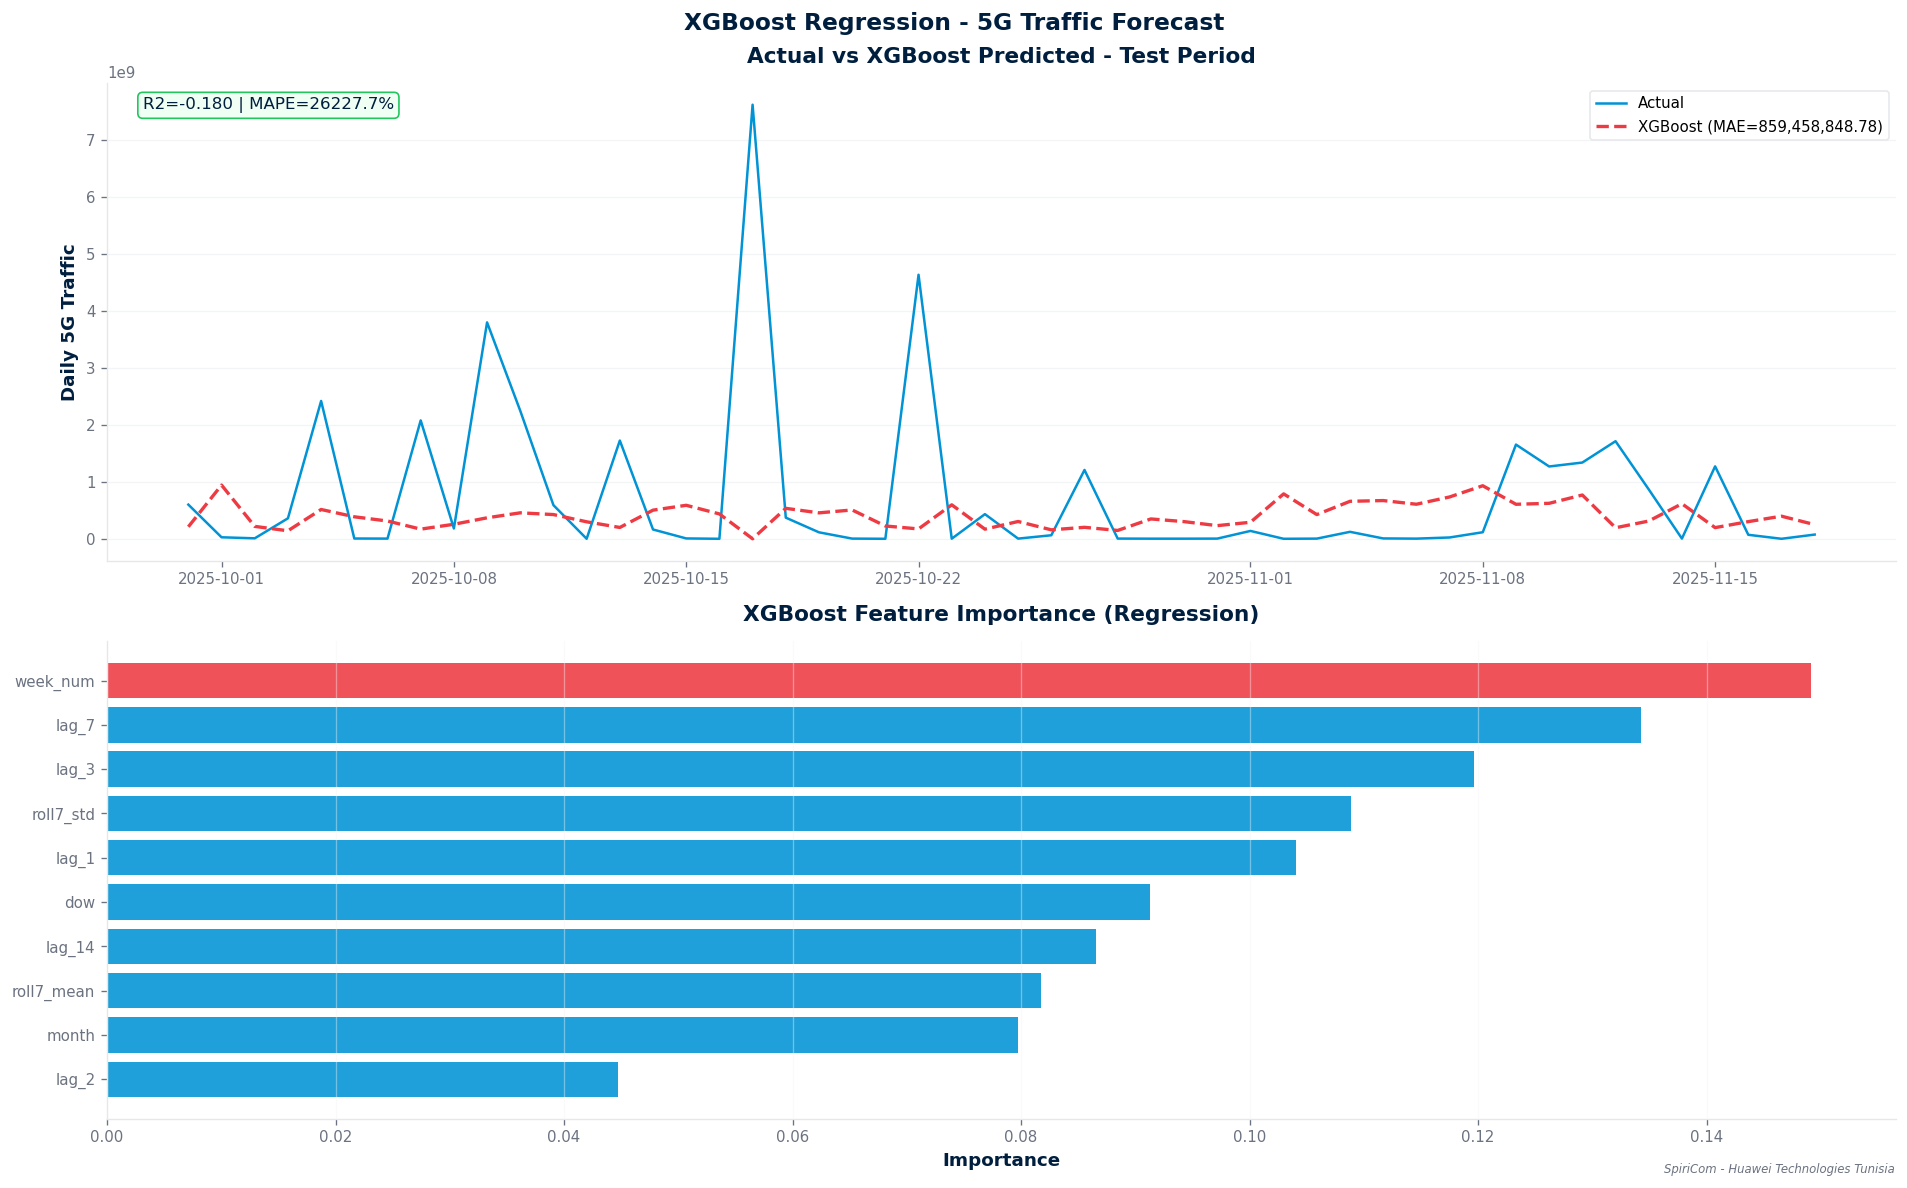

In [17]:
if daily_5g is not None and xgb_reg_mae is not None:
    dates_te = ts_feat['ds'].iloc[split_ts:].values
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    fig.suptitle('XGBoost Regression - 5G Traffic Forecast',
                 fontsize=14, fontweight='bold', color=HW['navy'])

    ax = axes[0]
    ax.plot(dates_te, y_te_r.values, color=HW['blue'], lw=1.5, label='Actual')
    ax.plot(dates_te, pred_xgb_r, color=HW['red'], lw=2.0, ls='--',
            label=f'XGBoost (MAE={xgb_reg_mae:,.2f})')
    ax.set_title('Actual vs XGBoost Predicted - Test Period', pad=12)
    ax.set_ylabel('Daily 5G Traffic')
    ax.legend()
    ax.text(0.02, 0.97, f'R2={xgb_reg_r2:.3f} | MAPE={xgb_reg_mape:.1f}%',
            transform=ax.transAxes, fontsize=10, va='top', color=HW['navy'],
            bbox=dict(boxstyle='round', facecolor='#F0FFF4', edgecolor=HW['green']))

    ax2 = axes[1]
    fi_reg = pd.Series(reg.feature_importances_,
                       index=LAG_FEATURES).sort_values(ascending=True)
    bar_c = [HW['red'] if v == fi_reg.max() else HW['blue'] for v in fi_reg]
    ax2.barh(fi_reg.index, fi_reg.values, color=bar_c, alpha=0.88)
    ax2.set_title('XGBoost Feature Importance (Regression)', pad=12)
    ax2.set_xlabel('Importance')
    ax2.grid(axis='x', alpha=0.4); ax2.grid(axis='y', visible=False)
    add_watermark(fig)
    plt.tight_layout()
    save_fig('figD1_xgboost_5g_regression')
    plt.show()


## Section E — Brand Traffic Forecast
NB02-9: a **seasonal-naive baseline** (value 7 days earlier) joins Prophet so the
per-brand winner is a real comparison, not a hardcoded string.

In [18]:
brand_scores = []
brand_forecasts_list = []

def seasonal_naive(train_y, test_len, season=7):
    last = train_y[-season:]
    reps = int(np.ceil(test_len / season))
    return np.tile(last, reps)[:test_len]

if brand_daily is None:
    print('Brand data unavailable - skipping Section E')
else:
    brands = brand_daily['brand'].unique()
    print(f'Forecasting {len(brands)} brands: {brands.tolist()}')
    for brand in brands:
        bdf = (brand_daily[brand_daily['brand'] == brand]
               .sort_values('ds').reset_index(drop=True))
        if len(bdf) < 14:
            print(f'  {brand}: too few points ({len(bdf)}) - skipped')
            continue
        nb_split = int(len(bdf) * SPLIT_RATIO)
        b_train = bdf.iloc[:nb_split].rename(columns={'traffic': 'y'})[['ds', 'y']]
        b_test  = bdf.iloc[nb_split:].rename(columns={'traffic': 'y'})[['ds', 'y']]

        # Seasonal-naive baseline
        snaive_pred = seasonal_naive(b_train['y'].values, len(b_test))
        snaive_mae  = mean_absolute_error(b_test['y'].values, snaive_pred)
        snaive_mape = mape_score(b_test['y'].values, snaive_pred)

        # Prophet
        prophet_b_mae = None
        try:
            mp = Prophet(seasonality_mode='multiplicative',
                         weekly_seasonality=True, yearly_seasonality=False,
                         changepoint_prior_scale=0.1, interval_width=0.80)
            mp.fit(b_train)
            future_b = mp.make_future_dataframe(periods=len(b_test) + 30, freq='D')
            fc_b = mp.predict(future_b)
            preds_b = (fc_b[fc_b['ds'].isin(b_test['ds'])]['yhat']
                       .clip(lower=0).values)
            if len(preds_b) == len(b_test):
                prophet_b_mae  = mean_absolute_error(b_test['y'].values, preds_b)
                prophet_b_mape = mape_score(b_test['y'].values, preds_b)
        except Exception as e:
            print(f'  {brand}: Prophet failed ({e})')

        # NB02-9: real winner
        if prophet_b_mae is not None and prophet_b_mae <= snaive_mae:
            winner, w_mae, w_mape = 'prophet', prophet_b_mae, prophet_b_mape
        else:
            winner, w_mae, w_mape = 'seasonal_naive', snaive_mae, snaive_mape

        if winner == 'prophet':
            future_30 = fc_b.tail(30)[['ds', 'yhat']].copy()
            future_30.rename(columns={'yhat': 'forecast'}, inplace=True)
        else:
            fut_dates = pd.date_range(bdf['ds'].max() + pd.Timedelta(days=1),
                                      periods=30, freq='D')
            future_30 = pd.DataFrame({
                'ds': fut_dates,
                'forecast': seasonal_naive(bdf['traffic'].values, 30),
            })
        future_30['forecast'] = future_30['forecast'].clip(lower=0)
        future_30['brand']  = brand
        future_30['target'] = BRAND_TARGET or 'traffic'
        future_30['model']  = winner
        brand_forecasts_list.append(future_30)

        brand_scores.append({
            'brand': brand, 'model': winner,
            'mae': round(float(w_mae), 3), 'mape': round(float(w_mape), 2),
            'prophet_mae': round(float(prophet_b_mae), 3) if prophet_b_mae is not None else None,
            'snaive_mae': round(float(snaive_mae), 3),
            'n_test': len(b_test),
        })
        pm = f'{prophet_b_mae:,.2f}' if prophet_b_mae is not None else 'failed'
        print(f'  {brand:<20s} prophet MAE={pm}  snaive MAE={snaive_mae:,.2f}'
              f'  -> winner: {winner}')


12:31:04 - cmdstanpy - INFO - Chain [1] start processing


Forecasting 5 brands: ['APPLE', 'INFINIX', 'SAMSUNG', 'XIAOMI', 'OPPO']


12:31:04 - cmdstanpy - INFO - Chain [1] done processing
12:31:05 - cmdstanpy - INFO - Chain [1] start processing


  APPLE                prophet MAE=546,845,847.57  snaive MAE=578,064,951.86  -> winner: prophet


12:31:05 - cmdstanpy - INFO - Chain [1] done processing
12:31:05 - cmdstanpy - INFO - Chain [1] start processing
12:31:05 - cmdstanpy - INFO - Chain [1] done processing


  INFINIX              prophet MAE=19,301,355.45  snaive MAE=13,278,181.69  -> winner: seasonal_naive


12:31:05 - cmdstanpy - INFO - Chain [1] start processing
12:31:05 - cmdstanpy - INFO - Chain [1] done processing


  SAMSUNG              prophet MAE=394,550,113.52  snaive MAE=308,828,470.47  -> winner: seasonal_naive


12:31:06 - cmdstanpy - INFO - Chain [1] start processing
12:31:06 - cmdstanpy - INFO - Chain [1] done processing


  XIAOMI               prophet MAE=36,066,678.55  snaive MAE=36,380,338.32  -> winner: prophet
  OPPO                 prophet MAE=66,073,458.55  snaive MAE=133,634,937.07  -> winner: prophet



Brand Forecast Scores:
  brand          model            mae       mape    prophet_mae     snaive_mae  n_test
INFINIX seasonal_naive  13278181.6940   157.5600  19301355.4550  13278181.6940      36
 XIAOMI        prophet  36066678.5530   100.0000  36066678.5530  36380338.3160      38
   OPPO        prophet  66073458.5490 12162.6300  66073458.5490 133634937.0670      30
SAMSUNG seasonal_naive 308828470.4650  8021.5200 394550113.5160 308828470.4650      43
  APPLE        prophet 546845847.5670 35735.0300 546845847.5670 578064951.8570      28
  Saved: data\outputs\figures\figE2_brand_mae_comparison.png


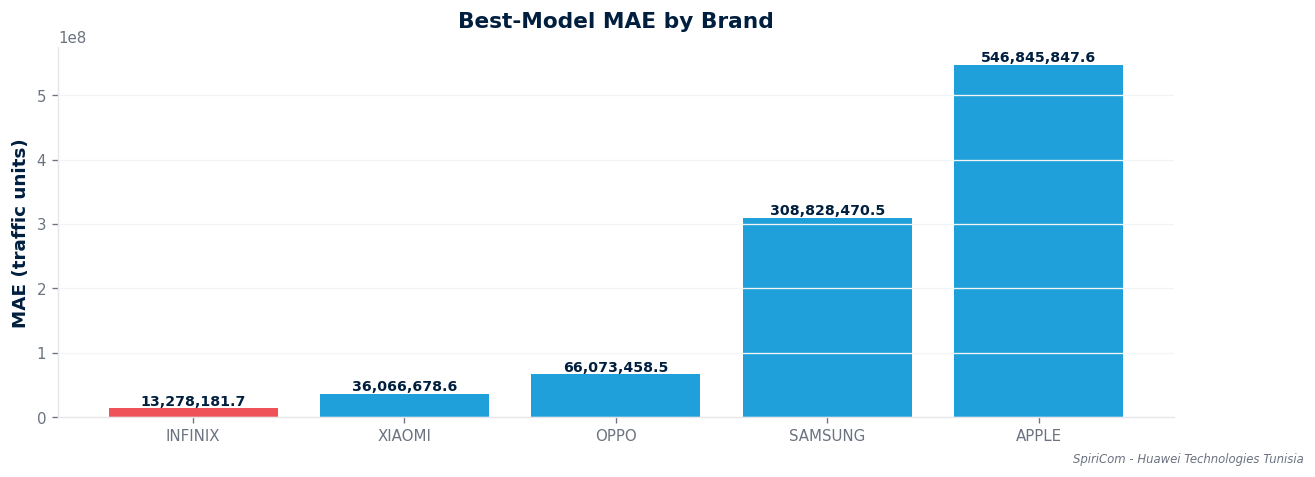

In [19]:
from IPython.display import display

if brand_daily is not None and len(brand_forecasts_list) > 0:
    all_fc_brands = pd.concat(brand_forecasts_list, ignore_index=True)
    fig = px.line(all_fc_brands, x='ds', y='forecast', color='brand',
                  title='30-Day Traffic Forecast by Device Brand',
                  labels={'ds': 'Date', 'forecast': 'Forecast Traffic',
                          'brand': 'Brand'},
                  color_discrete_sequence=PALETTE)
    fig.update_layout(**PLOTLY_LAYOUT)
    fig.write_html(str(FIG_DIR / 'figE1_brand_forecast.html'))
    display(fig)

    bs_df = pd.DataFrame(brand_scores).sort_values('mae')
    print('\nBrand Forecast Scores:')
    print(bs_df.to_string(index=False))

    fig2, ax = plt.subplots(figsize=(12, 4))
    colors_b = [HW['red'] if row.mae == bs_df['mae'].min() else HW['blue']
                for row in bs_df.itertuples()]
    ax.bar(bs_df['brand'], bs_df['mae'], color=colors_b, alpha=0.88)
    ax.set_title('Best-Model MAE by Brand', pad=12)
    ax.set_ylabel('MAE (traffic units)')
    for i, row in enumerate(bs_df.itertuples()):
        ax.text(i, row.mae + bs_df['mae'].max() * 0.01, f'{row.mae:,.1f}',
                ha='center', fontsize=8.5, color=HW['navy'], fontweight='bold')
    add_watermark(fig2)
    save_fig('figE2_brand_mae_comparison')
    plt.show()


## Section 9 — Model Comparison

In [20]:
rows = []
if f1_s is not None:
    rows.append({'model': 'XGBoost', 'target': 'session_flag', 'metric': 'F1',
                 'value': round(f1_s, 4), 'pass': f1_s > 0.72})
if auc_s is not None:
    rows.append({'model': 'XGBoost', 'target': 'session_flag', 'metric': 'AUC-ROC',
                 'value': round(auc_s, 4), 'pass': auc_s > 0.85})
if prophet_mae is not None:
    rows.append({'model': 'Prophet', 'target': 'traffic_5G', 'metric': 'MAE',
                 'value': round(prophet_mae, 2), 'pass': True})
    rows.append({'model': 'Prophet', 'target': 'traffic_5G', 'metric': 'MAPE',
                 'value': round(prophet_mape, 2), 'pass': prophet_mape < 20})
if arima_mae is not None:
    rows.append({'model': 'ARIMA', 'target': 'traffic_5G', 'metric': 'MAE',
                 'value': round(arima_mae, 2), 'pass': True})
    rows.append({'model': 'ARIMA', 'target': 'traffic_5G', 'metric': 'MAPE',
                 'value': round(arima_mape, 2), 'pass': arima_mape < 20})
if xgb_reg_mae is not None:
    rows.append({'model': 'XGBoost', 'target': 'traffic_5G', 'metric': 'MAE',
                 'value': round(xgb_reg_mae, 2), 'pass': True})
    rows.append({'model': 'XGBoost', 'target': 'traffic_5G', 'metric': 'MAPE',
                 'value': round(xgb_reg_mape, 2), 'pass': xgb_reg_mape < 20})
    rows.append({'model': 'XGBoost', 'target': 'traffic_5G', 'metric': 'R2',
                 'value': round(xgb_reg_r2, 4), 'pass': xgb_reg_r2 > 0.7})

compare_df = pd.DataFrame(rows)
if len(compare_df) > 0:
    print('=== MODEL COMPARISON ===')
    print(compare_df.to_string(index=False))
    print(f'\nPassed all targets: {bool(compare_df["pass"].all())}')


=== MODEL COMPARISON ===
  model       target  metric          value  pass
XGBoost session_flag      F1         0.9533  True
XGBoost session_flag AUC-ROC         0.9994  True
Prophet   traffic_5G     MAE 709063413.1400  True
Prophet   traffic_5G    MAPE      2214.9700 False
XGBoost   traffic_5G     MAE 859458848.7800  True
XGBoost   traffic_5G    MAPE     26227.7100 False
XGBoost   traffic_5G      R2        -0.1802 False

Passed all targets: False


  Saved: data\outputs\figures\fig09_model_comparison_mae.png


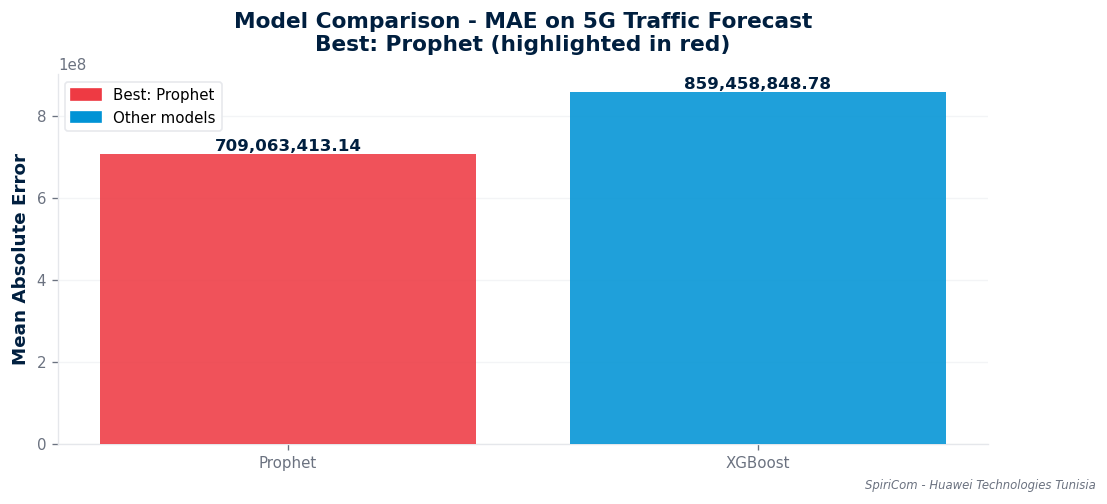

Best model for 5G traffic: Prophet


In [21]:
if len(compare_df) > 0 and daily_5g is not None:
    mae_rows = compare_df[(compare_df['target'] == 'traffic_5G') &
                          (compare_df['metric'] == 'MAE')].copy()
    if len(mae_rows) > 0:
        best_model = mae_rows.loc[mae_rows['value'].idxmin(), 'model']
        fig, ax = plt.subplots(figsize=(10, 4))
        colors_m = [HW['red'] if m == best_model else HW['blue']
                    for m in mae_rows['model']]
        bars = ax.bar(mae_rows['model'], mae_rows['value'],
                      color=colors_m, alpha=0.88, zorder=3)
        for bar, v in zip(bars, mae_rows['value']):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f'{v:,.2f}', ha='center', va='bottom', fontsize=10,
                    fontweight='bold', color=HW['navy'])
        ax.set_title('Model Comparison - MAE on 5G Traffic Forecast\n'
                     f'Best: {best_model} (highlighted in red)', pad=14)
        ax.set_ylabel('Mean Absolute Error')
        ax.legend(handles=[
            mpatches.Patch(color=HW['red'], label=f'Best: {best_model}'),
            mpatches.Patch(color=HW['blue'], label='Other models'),
        ])
        add_watermark(fig)
        save_fig('fig09_model_comparison_mae')
        plt.show()
        print(f'Best model for 5G traffic: {best_model}')


## Section 10 — Save Artifacts & Models
NB02-12: models are now serialized (the FastAPI endpoints need them).

In [22]:
# ── 10.1 prediction_scores.parquet ────────────────────────────
score_rows = []
base_row = {'region': 'ALL', 'target': 'traffic_5G'}
if prophet_mae is not None:
    base_row.update({'prophet_mae': prophet_mae, 'prophet_mape': prophet_mape})
if arima_mae is not None:
    base_row.update({'arima_mae': arima_mae, 'arima_mape': arima_mape})
if xgb_reg_mae is not None:
    base_row.update({'xgboost_mae': xgb_reg_mae, 'xgboost_mape': xgb_reg_mape,
                     'xgboost_r2': xgb_reg_r2})
mae_by_model = {k.replace('_mae', ''): v for k, v in base_row.items()
                if k.endswith('_mae')}
if mae_by_model:
    base_row['winner'] = min(mae_by_model, key=mae_by_model.get)
score_rows.append(base_row)

for bs in brand_scores:
    score_rows.append({
        'region': bs['brand'], 'target': BRAND_TARGET or 'traffic',
        'prophet_mae': bs.get('prophet_mae'),
        'snaive_mae': bs.get('snaive_mae'),
        'best_mae': bs['mae'], 'best_mape': bs['mape'],
        'winner': bs['model'],
    })

scores_df = pd.DataFrame(score_rows)
scores_path = MODEL_DIR / 'prediction_scores.parquet'
scores_df.to_parquet(scores_path, index=False)
print(f'Saved: {scores_path}')
print(scores_df.to_string(index=False))


Saved: models\prediction\prediction_scores.parquet
 region     target    prophet_mae  prophet_mape    xgboost_mae  xgboost_mape  xgboost_r2         winner     snaive_mae       best_mae  best_mape
    ALL traffic_5G 709063413.1445     2214.9712 859458848.7800    26227.7109     -0.1802        prophet            NaN            NaN        NaN
  APPLE traffic_5g 546845847.5670           NaN            NaN           NaN         NaN        prophet 578064951.8570 546845847.5670 35735.0300
INFINIX traffic_5g  19301355.4550           NaN            NaN           NaN         NaN seasonal_naive  13278181.6940  13278181.6940   157.5600
SAMSUNG traffic_5g 394550113.5160           NaN            NaN           NaN         NaN seasonal_naive 308828470.4650 308828470.4650  8021.5200
 XIAOMI traffic_5g  36066678.5530           NaN            NaN           NaN         NaN        prophet  36380338.3160  36066678.5530   100.0000
   OPPO traffic_5g  66073458.5490           NaN            NaN           NaN   

In [23]:
# ── 10.2 forecasts.parquet ────────────────────────────────────
fc_rows = []
if prophet_fc is not None:
    for _, row in prophet_fc.iterrows():
        fc_rows.append({'date': str(row['ds'].date()), 'region': 'ALL',
                        'forecast': round(float(row['yhat']), 2),
                        'model': 'prophet', 'target': 'traffic_5G'})
if daily_5g is not None and xgb_reg_mae is not None:
    for d, p in zip(ts_feat['ds'].iloc[split_ts:].values, pred_xgb_r):
        fc_rows.append({'date': str(pd.Timestamp(d).date()), 'region': 'ALL',
                        'forecast': round(float(p), 2),
                        'model': 'xgboost', 'target': 'traffic_5G'})
if brand_daily is not None and len(brand_forecasts_list) > 0:
    for _, row in all_fc_brands.iterrows():
        fc_rows.append({'date': str(pd.Timestamp(row['ds']).date()),
                        'region': row['brand'],
                        'forecast': round(float(row['forecast']), 2),
                        'model': row['model'],
                        'target': BRAND_TARGET or 'traffic'})
if fc_rows:
    fc_df = pd.DataFrame(fc_rows)
    fc_path = MODEL_DIR / 'forecasts.parquet'
    fc_df.to_parquet(fc_path, index=False)
    print(f'Saved: {fc_path} ({len(fc_df):,} rows)')
else:
    print('No forecast rows to save')


Saved: models\prediction\forecasts.parquet (230 rows)


In [24]:
# ── 10.3 Serialize models (NB02-12) ───────────────────────────
if SESSION_TARGET is not None:
    joblib.dump(clf, MODEL_DIR / 'session_flag_xgb.joblib')
    json.dump(feat_cols_session,
              open(MODEL_DIR / 'session_flag_features.json', 'w'))
    print(f'Saved: session_flag_xgb.joblib ({SESSION_MODE})')
if daily_5g is not None and xgb_reg_mae is not None:
    joblib.dump(reg, MODEL_DIR / 'traffic5g_xgb.joblib')
    json.dump(LAG_FEATURES, open(MODEL_DIR / 'traffic5g_features.json', 'w'))
    print('Saved: traffic5g_xgb.joblib')
if daily_5g is not None and prophet_mae is not None:
    with open(MODEL_DIR / 'traffic5g_prophet.json', 'w') as f:
        f.write(model_to_json(m_prophet))
    print('Saved: traffic5g_prophet.json')


Saved: session_flag_xgb.joblib (cross-sectional)
Saved: traffic5g_xgb.joblib
Saved: traffic5g_prophet.json


In [25]:
# ── 10.4 forecast_results.json + final summary ────────────────
fc_5g_growth = None
fc_5g_trend = 'stable'
if prophet_fc is not None:
    first_fc = float(prophet_fc['yhat'].iloc[0])
    last_fc  = float(prophet_fc['yhat'].iloc[-1])
    if first_fc > 0:
        fc_5g_growth = round(((last_fc - first_fc) / first_fc) * 100, 1)
        fc_5g_trend = ('up' if fc_5g_growth > 2
                       else 'down' if fc_5g_growth < -2 else 'stable')

# NB02-10: predicted-class rate, not mean probability
session_active_pct = None
if SESSION_TARGET is not None:
    session_active_pct = round(float((y_prob_s > 0.5).mean()) * 100, 1)

top_brand = None
if brand_scores:
    top_brand = min(brand_scores, key=lambda x: x['mae'])['brand']

forecast_results = {
    'generated_at'          : datetime.now().isoformat(),
    'traffic_scale'         : 'raw (log1p back-transformed)' if TRAFFIC_IS_LOG else 'raw',
    'session_mode'          : SESSION_MODE,
    'traffic_5g_growth_pct' : fc_5g_growth,
    'traffic_5g_trend'      : fc_5g_trend,
    'session_active_pct'    : session_active_pct,
    'session_trend'         : 'stable',
    'top_brand'             : top_brand,
    'models_run': {
        'prophet': prophet_mae is not None,
        'arima'  : arima_mae is not None,
        'xgboost': xgb_reg_mae is not None,
        'session': SESSION_TARGET is not None,
    },
    'prophet_5g_mae'  : round(prophet_mae, 3) if prophet_mae is not None else None,
    'prophet_5g_mape' : round(prophet_mape, 2) if prophet_mape is not None else None,
    'prophet_5g_smape': round(prophet_smape, 2) if prophet_smape is not None else None,
    'arima_5g_mae'    : round(arima_mae, 3) if arima_mae is not None else None,
    'arima_5g_mape'   : round(arima_mape, 2) if arima_mape is not None else None,
    'arima_5g_smape'  : round(arima_smape, 2) if arima_smape is not None else None,
    'xgboost_5g_mae'  : round(xgb_reg_mae, 3) if xgb_reg_mae is not None else None,
    'xgboost_5g_mape' : round(xgb_reg_mape, 2) if xgb_reg_mape is not None else None,
    'xgboost_5g_smape': round(xgb_reg_smape, 2) if xgb_reg_smape is not None else None,
    'xgboost_5g_r2'   : round(xgb_reg_r2, 4) if xgb_reg_r2 is not None else None,
    'session_f1'     : round(f1_s, 3) if f1_s is not None else None,
    'session_auc'    : round(auc_s, 3) if auc_s is not None else None,
}
json_path = OUT_DIR / 'forecast_results.json'
with open(json_path, 'w') as f:
    json.dump(forecast_results, f, indent=2, default=str)
print(f'Saved: {json_path}')
print(json.dumps(forecast_results, indent=2, default=str))

# NB02-11: summary built from the comparison table only - cannot crash
print('\n' + '=' * 60)
print('NOTEBOOK 02 - KPI FORECASTING COMPLETE')
print('=' * 60)
if len(compare_df) > 0:
    for r in compare_df.itertuples():
        flag = 'OK' if r._5 else 'BELOW TARGET'   # 'pass' column
        print(f'  {r.model:<10s} {r.target:<14s} {r.metric:<8s} '
              f'{r.value:<12} {flag}')
print('\nArtifacts:')
print(f'  {MODEL_DIR}/prediction_scores.parquet')
print(f'  {MODEL_DIR}/forecasts.parquet')
print(f'  {MODEL_DIR}/*.joblib, traffic5g_prophet.json')
print(f'  {OUT_DIR}/forecast_results.json')
print('\nIMPORTANT: metrics are now on the RAW traffic scale (NB02-3).')
print('Re-sync the TRAINING constant in Forecasting.jsx with these values.')
print('\nNext -> Run 03_Churn_EDA.ipynb')


Saved: data\outputs\forecast_results.json
{
  "generated_at": "2026-06-20T12:31:08.768635",
  "traffic_scale": "raw",
  "session_mode": "cross-sectional",
  "traffic_5g_growth_pct": 98.9,
  "traffic_5g_trend": "up",
  "session_active_pct": 5.5,
  "session_trend": "stable",
  "top_brand": "INFINIX",
  "models_run": {
    "prophet": true,
    "arima": false,
    "xgboost": true,
    "session": true
  },
  "prophet_5g_mae": 709063413.144,
  "prophet_5g_mape": 2214.97,
  "prophet_5g_smape": 156.09,
  "arima_5g_mae": null,
  "arima_5g_mape": null,
  "arima_5g_smape": null,
  "xgboost_5g_mae": 859458848.78,
  "xgboost_5g_mape": 26227.71,
  "xgboost_5g_smape": 149.74,
  "xgboost_5g_r2": -0.1802,
  "session_f1": 0.953,
  "session_auc": 0.999
}

NOTEBOOK 02 - KPI FORECASTING COMPLETE
  XGBoost    session_flag   F1       0.9533       OK
  XGBoost    session_flag   AUC-ROC  0.9994       OK
  Prophet    traffic_5G     MAE      709063413.14 OK
  Prophet    traffic_5G     MAPE     2214.97      BELOW